# Experiment 1: Skill Frequency in Data Science Job Postings

Core skills such as Python, SQL, and statistics will have the highest frequency across job postings, indicating baseline requirements for data science roles -- does it supports by the real world data? 

This notebook tests the hypothesis that core skills such as Python, SQL, and statistics appear most frequently across data science job postings.


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install mlxtend


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from helpers import parse_salary, extract_skill_frequencies, SKILL_PATTERNS
from job_dataset_union import build_unified_jobs_df

In [2]:
data_paths = [
    # Dataset 1 
    Path("data/glassdoor_jobs_2023.csv"),
    # Dataset 2
    Path("data/data_science_job_posts_2025.csv"),
]

df = build_unified_jobs_df()

required_column = "job_description_skills"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in the unified dataset.")

job_descriptions = df[required_column].fillna("").astype(str)
print(f"Loaded {len(df)} job postings from {', '.join(str(path) for path in data_paths)}.")
print(df['source_dataset'].value_counts())


Loaded 2444 job postings from data/glassdoor_jobs_2023.csv, data/data_science_job_posts_2025.csv.
source_dataset
glassdoor_2023                 1500
data_science_job_posts_2025     944
Name: count, dtype: int64


In [3]:
df.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\nA Data Scientist at ExploreLearn...,glassdoor_2023,4.2,Cambium Learning Group\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\n\nChanging the world through digi...,glassdoor_2023,4.4,Adobe\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\nRanked by Forbes as one of the w...,glassdoor_2023,3.9,IBM\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
2439,data scientist,"Bengaluru, Karnataka, India",NaN,"€33,288 - €53,080",Technology,"['pytorch', 'python', 'sql', 'machine learning...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,NaN,company_171,a day ago,"Armonk, NY, US",Public,"524,598",€120.29B
2440,machine learning engineer,"Melbourne, Victoria, Australia",NaN,"€64,290",Retail,"['amazon', 'machine learning']",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,NaN,company_134,a month ago,"Seattle, WA, US",Public,"865,456",€838.78B
2441,data scientist,"McLean, VA",NaN,"€145,904 - €166,510",Retail,"['spark', 'aws', 'r', 'python', 'scala', 'sql'...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,midlevel,on-site,company_395,11 days ago,"McLean, VA, US",Public,"55,150",€36.29B
2442,data scientist,"New York, NY",NaN,"€159,149 - €181,595",Retail,"['spark', 'aws', 'r', 'python', 'scala', 'sql'...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,midlevel,on-site,company_395,17 days ago,"McLean, VA, US",Public,"55,110",€36.34B
2443,data scientist,"San Diego, CA",NaN,"€195,486 - €201,926",Technology,"['r', 'python', 'scala', 'sql', 'machine learn...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,on-site,company_844,8 days ago,"Mountain View, CA, US",Public,"17,040",€95.22B


In [3]:
skill_frequency = extract_skill_frequencies(job_descriptions, SKILL_PATTERNS)

skill_frequency

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,984,40.26
1,Python,796,32.57
2,SQL,533,21.81
3,R,449,18.37
4,Statistics,320,13.09
...,...,...,...
59,LightGBM,1,0.04
60,Plotly,1,0.04
61,PostgreSQL,0,0.00
62,MongoDB,0,0.00


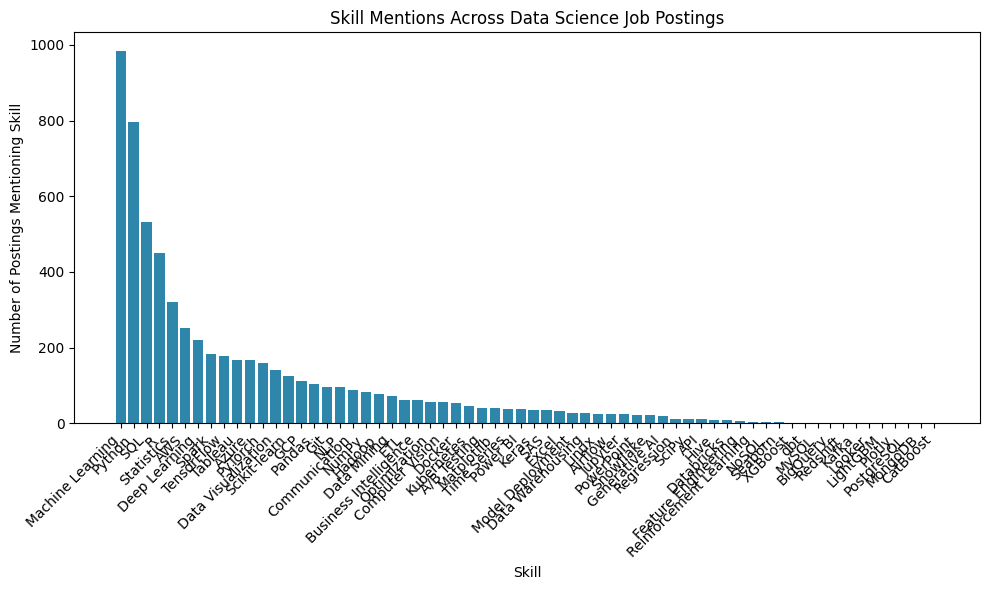

In [4]:
plt.figure(figsize=(10, 6))
plt.bar(skill_frequency["Skill"], skill_frequency["Mention Count"], color="#2E86AB")
plt.title("Skill Mentions Across Data Science Job Postings")
plt.xlabel("Skill")
plt.ylabel("Number of Postings Mentioning Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
core_skills = skill_frequency[skill_frequency["Skill"].isin(["Machine Learning", 
                                                             "Deep Learning",
                                                             "NLP",
                                                             "AWS",
                                                             "Python",
                                                             "SQL",
                                                             "Statistics"])]

core_skills

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,984,40.26
1,Python,796,32.57
2,SQL,533,21.81
4,Statistics,320,13.09
5,AWS,253,10.35
6,Deep Learning,220,9.00
17,NLP,95,3.89


## Interpretation

The hypothesis is **partially supported** by this dataset. While Python and statistics appear as baseline skills, Machine Learning dominates as the most frequently mentioned skill, followed by Python, SQL, and statistics.

Based on the actual data from 2,445 job postings, the ranking of core skills is:

- Machine Learning: 984 postings (40.26%)
- Python: 796 postings (32.57%)
- SQL: 533 postings (21.81%)
- Statistics: 320 postings (13.09%)
- AWS: 253 postings (10.35%)
- Deep Learning: 220 postings (9.00%)
- NLP: 95 postings (3.89%)

This suggests that Machine Learning has become a fundamental requirement in data science roles, surpassing traditional programming and statistical skills in frequency. Python remains a strong baseline, while SQL and statistics are important but less dominant than expected. Cloud platforms like AWS also show significant presence, indicating the growing importance of cloud infrastructure in data science.